In [1]:
import os

datadir = os.path.join(os.getcwd(), "../datasets")
importdir = os.path.join(os.getcwd(), "../pdetransformer")

# Add `importdir` to sys.path to enable imports from pdetransformer
import sys
if importdir not in sys.path:
    sys.path.append(importdir)
    
import h5py
import torch

In [2]:
import torch

def generateSineDatasets(N: int, T: int, D: int, P: int):
    positions = torch.randn(N, 1, D, P).repeat(1, T, 1, 1)         # positions of points
    timestep_influence = torch.arange(0, 1.0, 1.0/T).unsqueeze(0).unsqueeze(-1).unsqueeze(-1).repeat(N, 1, D, P)
    print(timestep_influence.shape)
    targets = torch.sin(positions+3*timestep_influence)              # sine of the positions as targets
    features = torch.zeros(N, T, 0, P)          # no additional features
    return (positions, targets, features, 1.0/T)

x, y, fx, dt = generateSineDatasets(100, 10, 2, 1000)
print(x.shape, y.shape, fx.shape, dt)

with h5py.File(os.path.join(datadir, "test.hdf5"), "w") as new_dset:
    sims = new_dset.create_group("sims")
    sims.attrs.update({
        "PDE": "2D-Sine",
        "Input Fields": [],
        "Input Fields Scheme": "",
        "Output Fields": ["sine_x", "sine_y"],
        "Output Fields Scheme": "xy",
        "Constants": ["Random1", "Random2"],
        "Dt": dt
    })
    for n in range(x.shape[0]):
        sim_group = sims.create_group(f"sim{n}")
        sim_group.create_dataset("x", data=x[n].numpy())
        sim_group.create_dataset("y", data=y[n].numpy())
        sim_group.create_dataset("fx", data=fx[n].numpy())
        sim_group.attrs.update({
            "Random1": float(torch.randn(1)),
            "Random2": float(torch.randn(1))
        })

torch.Size([100, 10, 2, 1000])
torch.Size([100, 10, 2, 1000]) torch.Size([100, 10, 2, 1000]) torch.Size([100, 10, 0, 1000]) 0.1


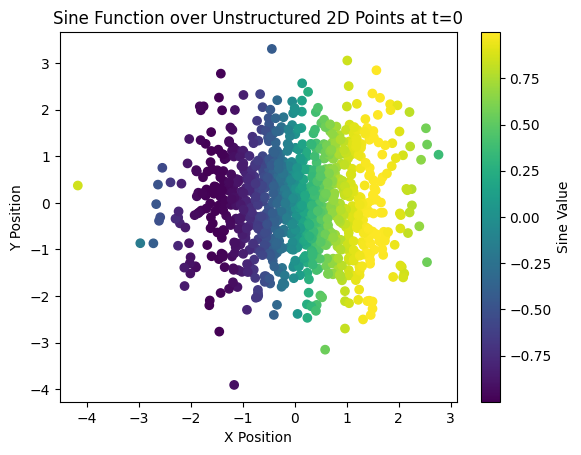

In [3]:
import matplotlib.pyplot as plt

# Visualize one sample
sample_idx = 0
time_idx = 0
plt.scatter(x[sample_idx, time_idx, 0].numpy(), x[sample_idx, time_idx, 1].numpy(), c=y[sample_idx, time_idx, 0].numpy())
plt.colorbar(label='Sine Value')
plt.title('Sine Function over Unstructured 2D Points at t=0')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

In [ ]:
%load_ext autoreload
%autoreload 1

%aimport pdetransformer.data.pbdlu_dataloader.dataset
%aimport pdetransformer.data.pbdlu_dataloader.normalization

import pdetransformer.data.pbdlu_dataloader.dataset as dataset
import pdetransformer.data.pbdlu_dataloader.normalization as norm

/home/tobias/pde-transformer-idp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Success: Loaded test with 100 simulations and 10 samples each.
Positions shape: torch.Size([4, 1, 2, 1000])
Targets shape: torch.Size([4, 1, 2, 1000])
Features shape: torch.Size([4, 1, 0, 1000])
Constants: torch.Size([4, 2])


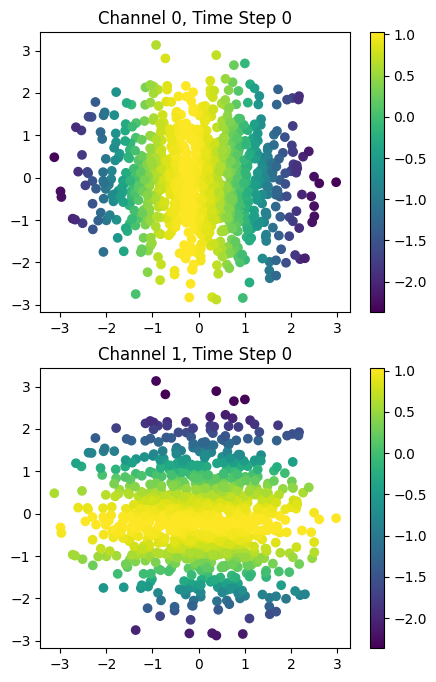

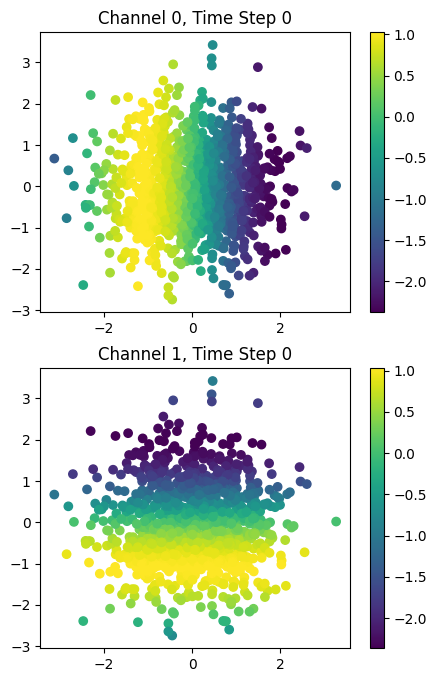

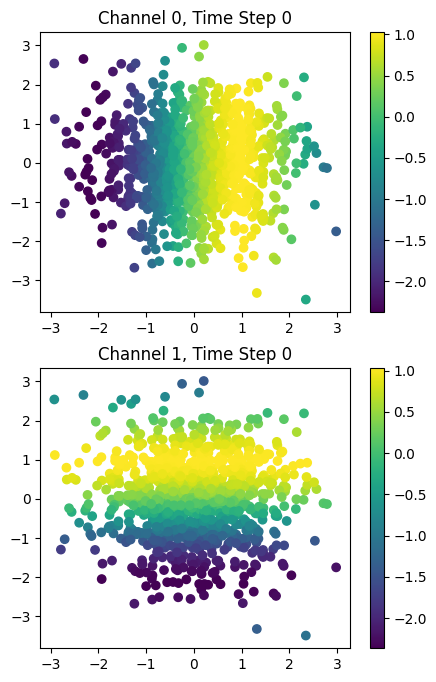

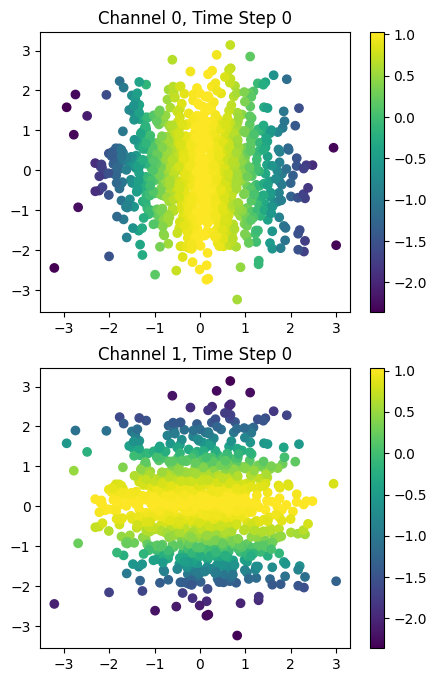

In [ ]:
try:
    T = 1
    d = dataset.PBDLUDataset(
        dset_path="/home/tobias/pde-transformer-idp/datasets/test.hdf5",
        time_steps=T,
        intermediate_time_steps=True,
        step_size=1,
        # normalize_pos=norm.MinMaxNorm,
        # normalize_in=norm.StdNorm,
        normalize_out=norm.MeanStdNorm,
        # normalize_const=norm.MinMaxNorm,
    )
    
    dataloader = torch.utils.data.DataLoader(d, batch_size=4, shuffle=True)

    for batch in dataloader:
        batch_pos, batch_target, batch_feat, const = batch
        print("Positions shape:", batch_pos.shape)
        print("Targets shape:", batch_target.shape)
        print("Features shape:", batch_feat.shape)
        print("Constants:", const.shape)
        
        # Plot batch
        B, T, C, P = batch_target.shape
        for b in range(B):
            fig, ax = plt.subplots(C, T, figsize=(5*T, 4*C))
            for c in range(C):
                for t in range(T):
                    if T == 1 and C == 1:
                        pass
                    elif T == 1:
                        plt.sca(ax[c])
                    else:
                        plt.sca(ax[c, t])
                    plt.scatter(
                        batch_pos[b, t, 0, :],
                        batch_pos[b, t, 1, :],
                        c=batch_target[b, t, c, :],
                        cmap='viridis'
                    );
                    plt.title(f'Channel {c}, Time Step {t}');
                    plt.colorbar();
        plt.show()
        break
except Exception as e:
    print("An error occurred:", e)
finally:
    d.dset.close()

Success: Loaded test_elasticity with 972 simulations and 1 samples each.
Batch Positions shape: torch.Size([4, 1, 2, 972])
Batch Targets shape: torch.Size([4, 1, 1, 972])
Batch Features shape: torch.Size([4, 1, 0, 972])
Batch Constants shape: torch.Size([4, 0])


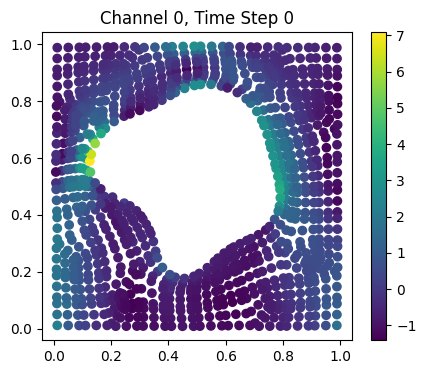

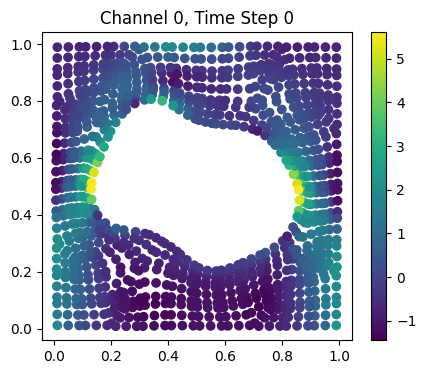

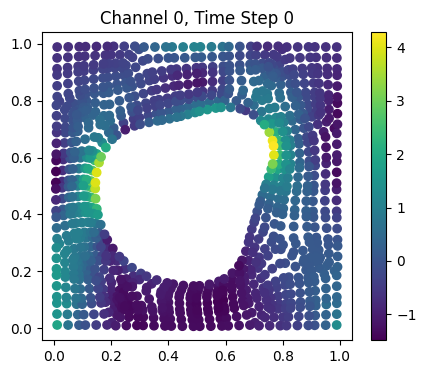

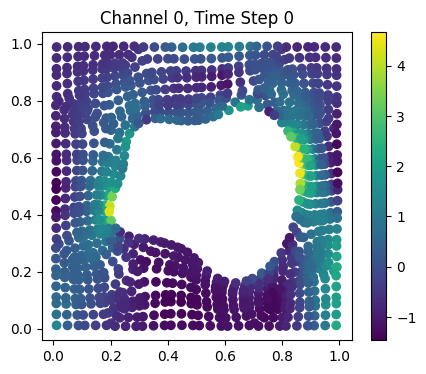

In [ ]:
from pdetransformer.data.pbdlu_dataloader.pbdlu_module import PBDLUDataModule
import pdetransformer.data.pbdlu_dataloader.normalization as norm
import matplotlib.pyplot as plt

data_module = PBDLUDataModule(
    dataset_path="/home/tobias/pde-transformer-idp/datasets/test_elasticity.hdf5",
    batch_size=4,
    num_workers=2,
    shuffle=True,
    all_time_steps=True,
    normalize_out=norm.MeanStdNorm
)

data_module.setup("fit")

for batch in data_module.train_dataloader():
    batch_pos, batch_target, batch_feat, batch_const = batch
    print("Batch Positions shape:", batch_pos.shape)
    print("Batch Targets shape:", batch_target.shape)
    print("Batch Features shape:", batch_feat.shape)
    print("Batch Constants shape:", batch_const.shape)
    
    # Plot batch
    B, T, C, P = batch_target.shape
    for b in range(B):
        fig, ax = plt.subplots(C, T, figsize=(5*T, 4*C))
        for c in range(C):
            for t in range(T):
                if T == 1 and C == 1:
                    pass
                elif T == 1:
                    plt.sca(ax[c])
                else:
                    plt.sca(ax[c, t])
                plt.scatter(
                    batch_pos[b, t, 0, :],
                    batch_pos[b, t, 1, :],
                    c=batch_target[b, t, c, :],
                    cmap='viridis'
                );
                plt.title(f'Channel {c}, Time Step {t}');
                plt.colorbar();
    plt.show()
    break

In [ ]:
import lightning as L
import torch

class ElasticityModule(L.LightningModule):
    def __init__(self, model, optimizer=None, scheduler=None):
        super().__init__()
        self.model = model
        self.criterion = torch.nn.MSELoss()
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.test_loss = torch.nn.MSELoss()
    

    def forward(self, x, fx=None, T=None):
        return self.model(x, fx, T)

    def training_step(self, batch, batch_idx):
        x, y, fx, const = batch
        x = x.transpose(-1, -2).squeeze(1).float()
        y = y.transpose(-1, -2).squeeze(1).float()
        fx = fx.transpose(-1, -2).squeeze(1).float()
        const = const.float()
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        self.log('train_loss', loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y, fx, const = batch
        y_pred = self(x)
        loss = self.criterion(y_pred, y)
        self.log('val_loss', loss)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y, fx, const = batch
        y_pred = self(x)
        loss = self.test_loss(y_pred, y)
        self.log('test_loss', loss)
        return loss
    
    def configure_optimizers(self):
        if self.optimizer == None:
            self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        if self.scheduler == None:
            return self.optimizer
        
        return {
            'optimizer': self.optimizer,
            'lr_scheduler': self.scheduler
        }

In [ ]:
# Settings from Transolver repository

transolver_config = {
   'space_dim': 2,
   'fun_dim': 0,
   'out_dim': 1,
   'n_hidden': 128,
   'n_head': 8,
   'n_layers': 8,
   'slice_num': 64,
   'ref': 8,
   'unified_pos': False
}


config = {   
   'max_grad_norm': 0.1,  
   'batch_size': 32, # Modified from 1
   'lr': 1e-3,
   
   # New setting for max epochs
   'max_epochs': 50,
}

In [ ]:
from pdetransformer.core.unstructured.Transolver_Irregular_Mesh import Model as TransolverIrregularMesh

# torch.set_float32_matmul_precision('highest')

transolver = TransolverIrregularMesh(**transolver_config)

optimizer = torch.optim.Adam(transolver.parameters(), lr=config['lr'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['max_epochs'])
lightning_module = ElasticityModule(transolver, optimizer, scheduler)

trainer = L.Trainer(gradient_clip_val=config['max_grad_norm'], max_epochs=config['max_epochs'], log_every_n_steps=1, limit_val_batches=0)
trainer.fit(lightning_module, data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | model     | Model   | 713 K  | train
1 | criterion | MSELoss | 0      | train
2 | test_loss | MSELoss | 0      | train
----------------------------------------------
713 K     Trainable params
0         Non-trainable params
713 K     Total params
2.855     Total estimated model params size (MB)
180       Modules in train mode
0         Modules in eval mode


Epoch 19: 100%|██████████| 195/195 [00:06<00:00, 29.79it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 195/195 [00:06<00:00, 29.45it/s, v_num=1]


Model(
  (preprocess): MLP(
    (linear_pre): Sequential(
      (0): Linear(in_features=2, out_features=256, bias=True)
      (1): GELU(approximate='none')
    )
    (linear_post): Linear(in_features=256, out_features=128, bias=True)
    (linears): ModuleList()
  )
  (blocks): ModuleList(
    (0-6): 7 x Transolver_block(
      (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (Attn): Physics_Attention_Irregular_Mesh(
        (softmax): Softmax(dim=-1)
        (dropout): Dropout(p=0.0, inplace=False)
        (in_project_x): Linear(in_features=128, out_features=128, bias=True)
        (in_project_fx): Linear(in_features=128, out_features=128, bias=True)
        (in_project_slice): Linear(in_features=16, out_features=64, bias=True)
        (to_q): Linear(in_features=16, out_features=16, bias=False)
        (to_k): Linear(in_features=16, out_features=16, bias=False)
        (to_v): Linear(in_features=16, out_features=16, bias=False)
        (to_out): Sequential(
         

Prediction shape: torch.Size([4, 972, 1])


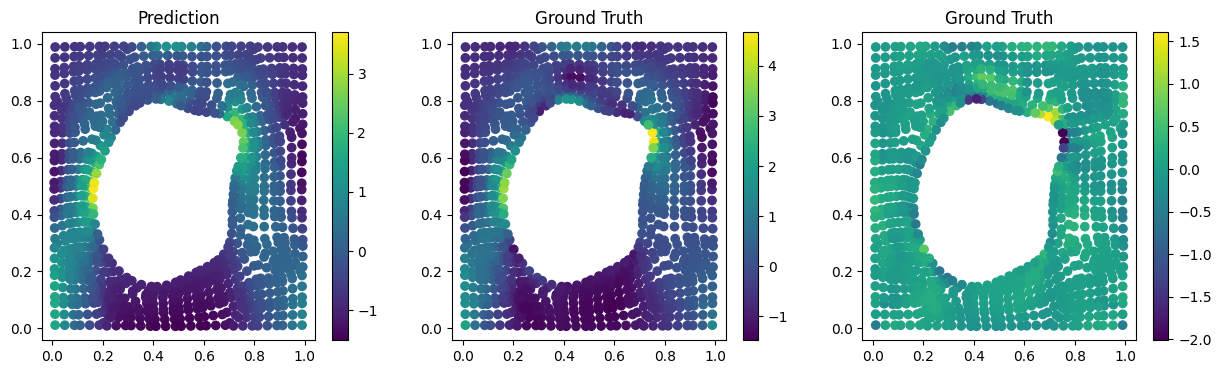

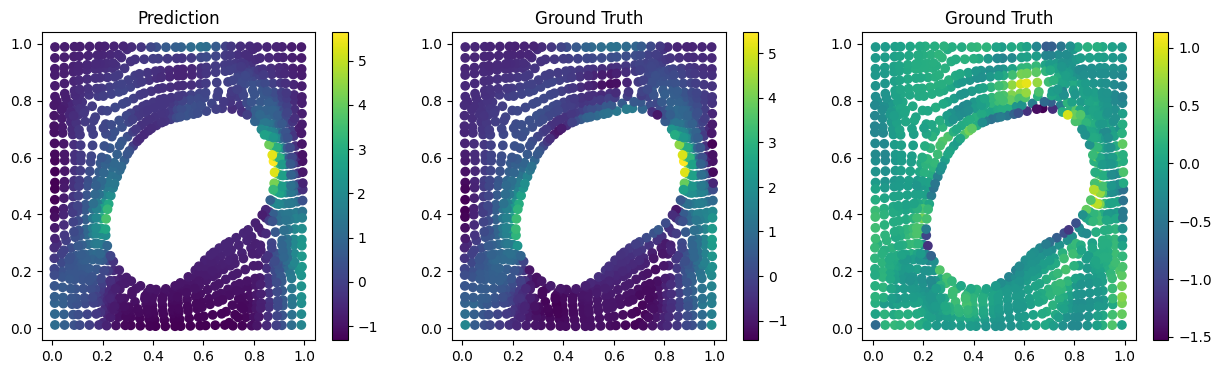

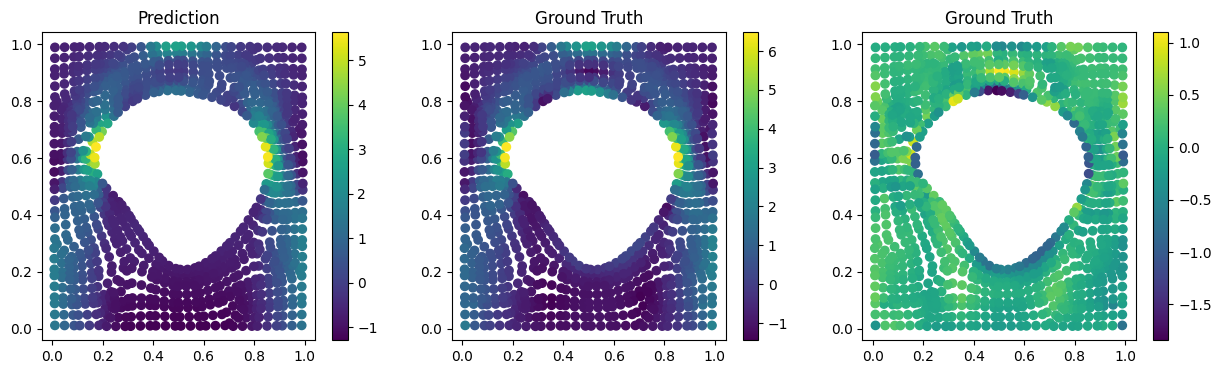

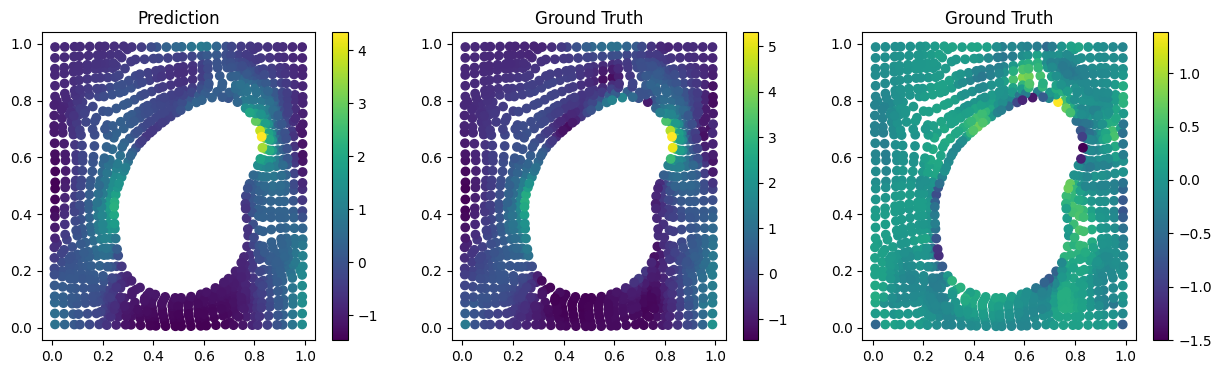

In [ ]:
transolver.eval()

prediction = transolver(batch_pos.transpose(-1, -2).squeeze(1).float(), None)
print("Prediction shape:", prediction.shape)
prediction = prediction.unsqueeze(1).transpose(-1, -2)

# Plot batch
B, T, C, P = prediction.shape
for b in range(B):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4*C))
    plt.sca(ax[0])
    plt.scatter(
        batch_pos.detach()[b, 0, 0, :],
        batch_pos.detach()[b, 0, 1, :],
        c=prediction.detach()[b, 0, c, :],
        cmap='viridis'
    );
    plt.title(f'Prediction');
    plt.colorbar();
    
    plt.sca(ax[1])
    plt.scatter(
        batch_pos.detach()[b, 0, 0, :],
        batch_pos.detach()[b, 0, 1, :],
        c=batch_target.detach()[b, 0, c, :],
        cmap='viridis'
    );
    plt.title(f'Ground Truth');
    plt.colorbar();
    
    plt.sca(ax[2])
    plt.scatter(
        batch_pos.detach()[b, 0, 0, :],
        batch_pos.detach()[b, 0, 1, :],
        c=prediction.detach()[b, 0, c, :]-batch_target.detach()[b, 0, c, :],
        cmap='viridis'
    );
    plt.title(f'Ground Truth');
    plt.colorbar();
plt.show()

In [ ]:
%load_ext autoreload
%autoreload 1
%aimport pdetransformer.data.pbdlu_dataloader.dataset
%aimport pdetransformer.data.pbdlu_dataloader.metadata_dataset
from pdetransformer.data.pbdlu_dataloader.dataset import PBDLUDataset
from pdetransformer.data.pbdlu_dataloader.metadata_dataset import MetadataDataset

d = PBDLUDataset(
        dset_path="/home/tobias/pde-transformer-idp/datasets/test_elasticity.hdf5",
        time_steps=1,
        intermediate_time_steps=True,
        step_size=1,
    )
metadata_dataset = MetadataDataset(dataset=d)

for item_dict in metadata_dataset:
    print(item_dict.keys())
    print(item_dict["metadata"])
    break  

/home/tobias/pde-transformer-idp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tobias/pde-transformer-idp/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/tobias/pde-transformer-idp/pdetransformer/data/pbdl_dataloader/dataset.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Success: Loaded test_elasticity with 972 simulations and 1 samples each.
dict_keys(['data', 'metadata'])
{'pde': 'elasticity', 'in_fields_scheme': '', 'in_fields': array([], dtype=float64), 'out_fields_scheme': 'q', 'out_fields': array(['sigma'], dtype=object), 'const': array([], dtype=float64), 'dt': np.float64(0.0), 'num_sims': 972, 'num_const': 0, 'num_frames': 1, 'num_points': 972, 'num_in_fields': 0, 'num_out_fields': 1, 'num_spatial_dim': 2}
